In [ ]:
import pandas as pd
import numpy as np
import sys

metadata_fname = "metadata/metadata_wide.tsv"
quants_fname = "data/proteins_normalized_wide.tsv"

metadata = pd.read_csv(metadata_fname, sep='\t', na_values=['NA'])
data = pd.read_csv(quants_fname, sep='\t')
data = data.fillna(0)
protein_names = data['protein'].values

print("Metadata shape:", metadata.shape)
print("Data shape:", data.shape)

Metadata shape: (104, 25)
Data shape: (2575, 105)


Data shape: (86, 2575)
Months: [22.42 14.37 14.37 17.36 11.15  5.85 22.42 29.33 22.42 20.48 17.46  5.85
 14.37  8.15 11.15 22.42 30.25 27.   14.37 20.48  5.85  5.85 27.   17.46
 29.33 11.15 20.48  8.15  8.15 17.46 20.58 11.15 27.   22.42 17.46 11.15
 14.37  5.85  8.15 29.33  8.15 22.42 27.   22.42  5.85 11.15  5.85 22.42
 17.46 30.25 20.48  5.85 20.58 17.36  8.15 14.37  8.15 11.15 14.37 22.42
 17.46  8.15 11.15  5.85 22.42 14.37  5.85 20.48 20.48 27.   20.48 17.46
  8.15 29.33 11.15 22.42 20.48 27.   14.37 30.25 14.37 17.36  8.15 11.15
 27.   22.42]
Sex: [1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 0 1 1 1 1 1 1 0 0 1
 0 0 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 1
 1 0 1 1 1 0 0 0 1 0 0 0]


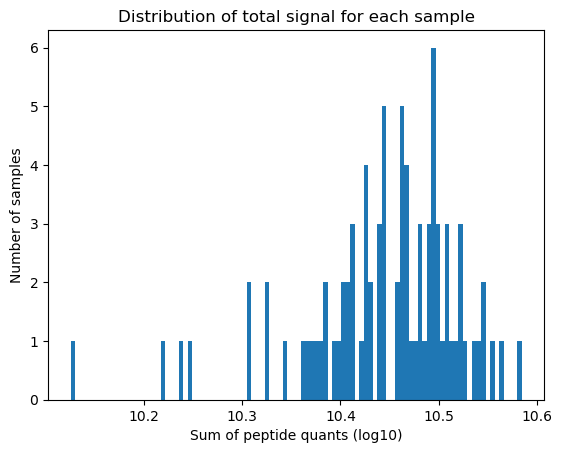

In [2]:
import matplotlib.pyplot as plt

valid_replicates = metadata[metadata['Age_months'].notna()]['replicate'].tolist()

X = []
month = []
sex = []

for idx in valid_replicates:
  for sample in data.columns[:]:
    if idx in sample:
      s_month = metadata[metadata['replicate'] == idx]['Age_months'].values[0]
      s_sex = metadata[metadata['replicate'] == idx]['Sex'].values[0]

      month.append(s_month)
      sex.append(s_sex)
      X.append(data[sample].values)

X = np.array(X)
X = np.power(2, X) # "unlog" X

month = np.array(month)
month = month.astype(float)

sex = np.array(sex)
sex = np.where(sex == "Male", 1, 0) # encode the sex array
sex = sex.astype(int)

print("Data shape:", X.shape)
print("Months:", month)
print("Sex:", sex)

total_signal = np.sum(X, axis=1)
plt.hist(np.log10(total_signal), bins = 100)
plt.title('Distribution of total signal for each sample')
plt.ylabel('Number of samples')
plt.xlabel('Sum of peptide quants (log10)')
plt.show()

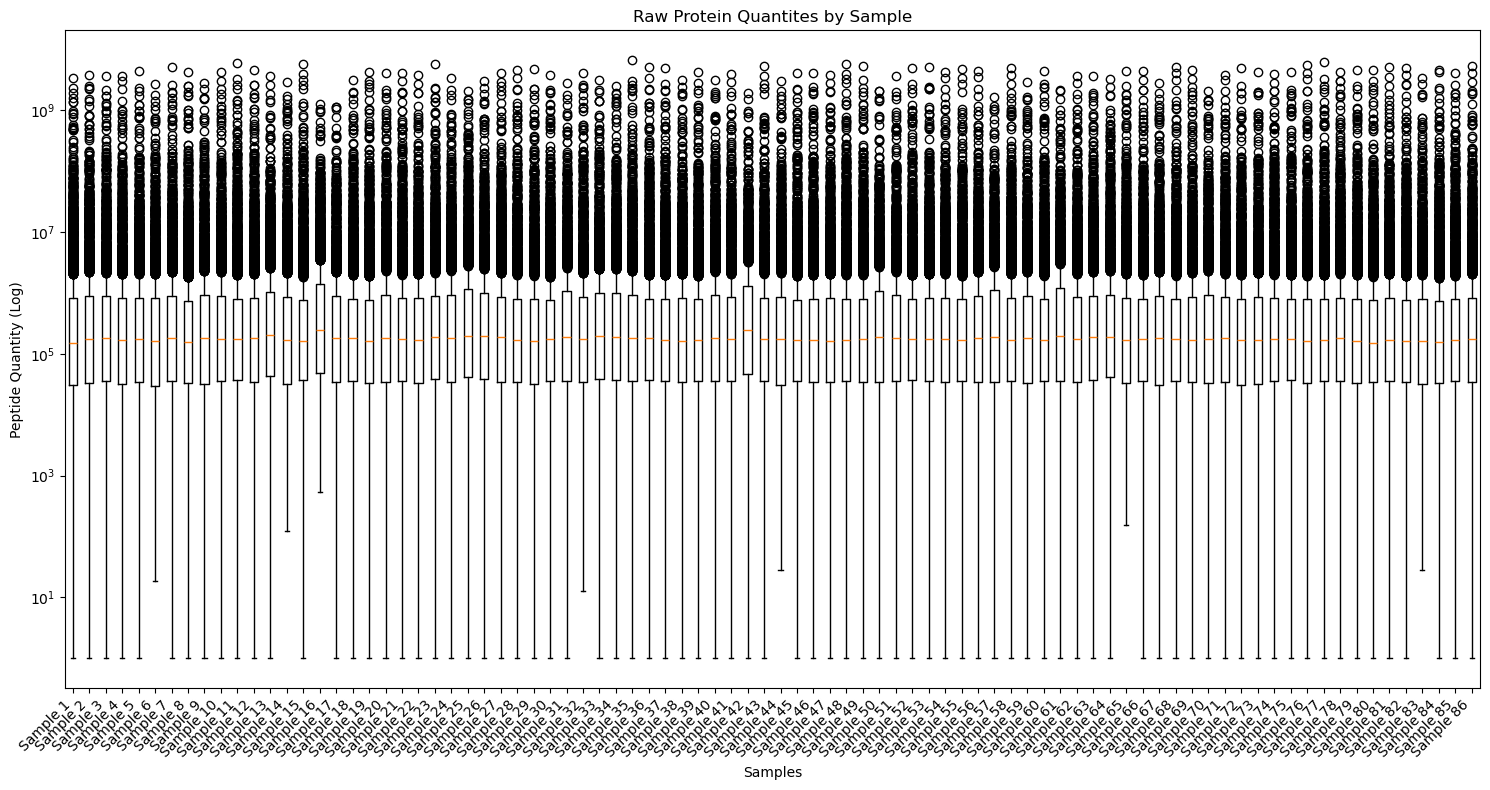

In [4]:
# Create the box plot
plt.figure(figsize=(15, 8))
plt.boxplot(X.T)  # Transpose the data

plt.title('Raw Protein Quantites by Sample')
plt.xlabel('Samples')
plt.ylabel('Peptide Quantity (Log)')
plt.xticks(range(1, X.shape[0] + 1), [f'Sample {i+1}' for i in range(X.shape[0])], rotation=45, ha='right')

# Use log scale for y-axis as peptide quantities often span several orders of magnitude
plt.yscale('log')

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Predict Coefficient of Variation as a function of protein abundance, sex, and is_old (age > 21 months)

In [9]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

X_log = np.log1p(X)

old_threshold = 21
is_old_sample = (month > old_threshold)  # older mice: >21 months
is_male_sample = sex              # sex: 1=male, 0=female

n_samples, n_proteins = X_log.shape

# Step 3: Compute CV and mean abundance per protein/group
rows_list = []

for p_idx in range(n_proteins):
    for old_val in [False, True]:       # young and old groups
        for male_val in [False, True]:  # female and male groups
            mask = (is_old_sample == old_val) & (is_male_sample == male_val)

            if np.sum(mask) < 2:  # Need ≥ 2 samples for CV
                continue

            subset_values = X_log[mask, p_idx]
            mean_abundance = np.mean(subset_values)
            std_abundance = np.std(subset_values, ddof=1)
            
            # Compute CV; avoid dividing by zero
            cv = std_abundance / mean_abundance if mean_abundance != 0 else np.nan
            
            row_dict = {
                "protein": f"protein_{p_idx}",
                "meanAbundance": mean_abundance,
                "CV": cv,
                "isOld": int(old_val),
                "isMale": int(male_val),
            }
            rows_list.append(row_dict)

df = pd.DataFrame(rows_list).dropna()

# Optional: Check distribution of CV and abundance
# df['logCV'] = np.log(df['CV'] + 1e-6)  # consider if CV is skewed

# Step 4: Fit the linear regression model
model = smf.ols("CV ~ meanAbundance + isOld + isMale", data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     CV   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     1378.
Date:                Thu, 04 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:03:32   Log-Likelihood:                 19794.
No. Observations:               10300   AIC:                        -3.958e+04
Df Residuals:                   10296   BIC:                        -3.955e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.1644      0.002     86.992

### Predict Coefficient of Variation as a function of protein abundance, sex, and age group (age 5-15 months vs 17-21 months)

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

X_log = np.log1p(X)

# Define age groups explicitly
young_mask = (month >= 5) & (month <= 15)
older_mask = (month >= 17) & (month <= 21)

# Exclude samples >21 months
valid_samples_mask = young_mask | older_mask

X_log_filtered = X_log[valid_samples_mask]
month_filtered = month[valid_samples_mask]
sex_filtered = sex[valid_samples_mask]

is_old_sample = older_mask[valid_samples_mask]  # older mice: 17-21 months
is_male_sample = sex_filtered                    # sex: 1=male, 0=female

n_samples, n_proteins = X_log_filtered.shape

# Compute CV and mean abundance per protein/group
rows_list = []

for p_idx in range(n_proteins):
    for old_val in [False, True]:       # young and older groups
        for male_val in [False, True]:  # female and male groups
            mask = (is_old_sample == old_val) & (is_male_sample == male_val)

            if np.sum(mask) < 2:  # Need ≥ 2 samples for CV
                continue

            subset_values = X_log_filtered[mask, p_idx]
            mean_abundance = np.mean(subset_values)
            std_abundance = np.std(subset_values, ddof=1)

            cv = std_abundance / mean_abundance if mean_abundance != 0 else np.nan

            row_dict = {
                "protein": f"protein_{p_idx}",
                "meanAbundance": mean_abundance,
                "CV": cv,
                "isOld": int(old_val),   # 0 for 0–15 months, 1 for 17–21 months
                "isMale": int(male_val),
            }
            rows_list.append(row_dict)

df = pd.DataFrame(rows_list).dropna()

# Fit linear regression model
model = smf.ols("CV ~ meanAbundance + isOld + isMale", data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     CV   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     1204.
Date:                Thu, 04 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:03:47   Log-Likelihood:                 19452.
No. Observations:               10300   AIC:                        -3.890e+04
Df Residuals:                   10296   BIC:                        -3.887e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.1593      0.002     82.366